INITIALIZATION

In [2]:
import numpy as np
import cv2
import os
from matplotlib import pyplot as plt
import sys
from scipy.ndimage import label, uniform_filter, binary_dilation, convolve, distance_transform_edt
from PIL import Image
np.set_printoptions(threshold=sys.maxsize)
from scipy.interpolate import splprep, splev
from numpy.polynomial import Chebyshev, Polynomial
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import r2_score
from io import StringIO
import lpips
import torch
import warnings

In [3]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder,filename))
        if img is not None:
            images.append(img)
    return images
pics = np.zeros(shape=(7, 256, 256, 3))
pics = load_images_from_folder('preliminaryTestPics')

COMPRESSION

In [4]:
#Image-level complexity from local LAB standard deviation.
def local_lab_complexity_score(img_bgr, window_size=7, statistic="median"):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float64)

    # OpenCV LAB - standard-like LAB
    L = lab[:, :, 0] * (100.0 / 255.0)
    A = lab[:, :, 1] - 128.0
    B = lab[:, :, 2] - 128.0

    std_maps = []
    for ch in (L, A, B):
        mu = uniform_filter(ch, size=window_size, mode="reflect")
        mu2 = uniform_filter(ch * ch, size=window_size, mode="reflect")
        var = np.maximum(mu2 - mu * mu, 0.0)
        std_maps.append(np.sqrt(var))

    local_std = np.sqrt(std_maps[0]**2 + std_maps[1]**2 + std_maps[2]**2)

    if statistic == "mean":
        score = float(np.mean(local_std))
    else:
        score = float(np.median(local_std))

    return score, local_std

def adaptive_deltaE_threshold(complexity_score, low_complexity=2.0, high_complexity=12.0, high_thresh=10.0, low_thresh=4.0):
    # Low complexity - higher threshold
    # High complexity - lower threshold
    
    t = (complexity_score - low_complexity) / (high_complexity - low_complexity)
    t = np.clip(t, 0.0, 1.0)
    thresh = high_thresh * (1.0 - t) + low_thresh * t
    return float(thresh)

Adaptive complexity score: 2.027
Adaptive thresh (deltaE-like): 7.989


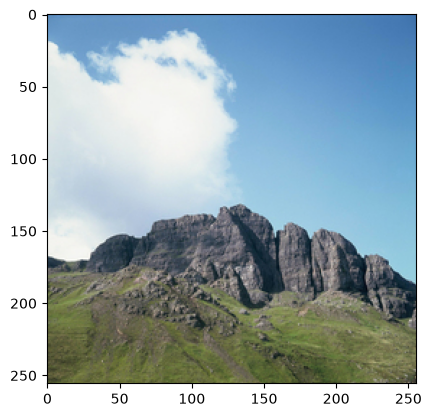

In [5]:
chosenImage = pics[3]

# Adaptive thresholding based on local LAB complexity
# calculate complexity score and local complexity map, indicates what areas are more complex
complexity_score, local_complexity_map = local_lab_complexity_score(chosenImage, window_size=7, statistic="median")

# color similarity threshold, usually 6-10 for deltaE
thresh = adaptive_deltaE_threshold(complexity_score, low_complexity=2.0, high_complexity=12.0, high_thresh=8.0, low_thresh=4.0)

print(f"Adaptive complexity score: {complexity_score:.3f}")
print(f"Adaptive thresh (deltaE-like): {thresh:.3f}")

# Color diversity score from CIELAB quantized bins
lab = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2LAB)

# Quantize channels
l_bin = (lab[:, :, 0] // 16).astype(np.int32)
a_bin = (lab[:, :, 1] // 16).astype(np.int32)
b_bin = (lab[:, :, 2] // 16).astype(np.int32)

key = l_bin * 16 * 16 + a_bin * 16 + b_bin
unique_colors = np.unique(key).size

if unique_colors < 75:
    pyrLevels = 1
elif unique_colors < 200:
    pyrLevels = 2
else:
    pyrLevels = 3

# Convert BGR to RGB for PIL (PIL expects RGB format)
chosenImageRGB = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2RGB)
im = Image.fromarray(chosenImageRGB)
im.save('test.png')
im.save('test.jpg')
im.save('test.tiff')
plt.imshow(cv2.cvtColor(chosenImage, cv2.COLOR_RGB2BGR))
plt.show()

In [6]:
# Apply bilateral filter
chosenImageFiltered = cv2.bilateralFilter(chosenImage, d=7, sigmaColor=35, sigmaSpace=35)

# Convert input image to CIELAB (OpenCV 8-bit encoding)
img = cv2.cvtColor(chosenImageFiltered, cv2.COLOR_BGR2LAB)

# Remove old compressed file if it exists
if os.path.exists("imComp.txt"):
    os.remove("imComp.txt")

# imgClusters[i,j] = cluster number pixel belongs to
imgClusters = np.ones((img.shape[0], img.shape[1]), dtype=int)

# List of perimeter pixels for each cluster
clusterEdges = []

# visited[i,j] = 1 - pixel not yet assigned to any cluster
# visited[i,j] = 0 - pixel already assigned
visited = np.ones((img.shape[0], img.shape[1]), dtype=int)

clusterNum = 1              # current cluster ID

# 8-connected neighborhood definition
structure = np.ones((3, 3), dtype=np.uint8)

# OpenCV LAB (8-bit) - approximate standard LAB:
# L*: [0,100], a*: [-128,127], b*: [-128,127]
img_f = img.astype(np.float64)
L_std = img_f[:, :, 0] * (100.0 / 255.0)
A_std = img_f[:, :, 1] - 128.0
B_std = img_f[:, :, 2] - 128.0

remaining = int(np.count_nonzero(visited))

# Continue until all pixels have been assigned
while remaining > 0:

    # Greedy assumption: all unvisited pixels could be in this cluster
    imgClusters[visited != 0] = clusterNum

    # ---- STEP 1: find the seed pixel and initialize cluster mean ----
    seed_positions = np.argwhere(visited == 1)
    if seed_positions.shape[0] == 0:
        break

    # ---- STEP 2: build the similarity mask (approx delta-E) ----
    startX, startY = seed_positions[0]
    seed_L = L_std[startX, startY]
    seed_A = A_std[startX, startY]
    seed_B = B_std[startX, startY]

    dL = L_std - seed_L
    dA = A_std - seed_A
    dB = B_std - seed_B

    # Euclidean distance in standard-like LAB coordinates
    dist = np.sqrt(dL**2 + dA**2 + dB**2)
    fitMask = (visited == 1) & (dist < thresh)

    # ---- STEP 3: connected component labeling (8-connected) ----
    labels, _ = label(fitMask, structure)

    # Label of the connected component containing the seed pixel
    seedLabel = labels[startX, startY]

    # region[i,j] = True ONLY for pixels reachable from the seed
    region = (labels == seedLabel)

    # ---- STEP 4: accept pixels in this connected component ----
    region_count = int(np.count_nonzero(region))
    if region_count == 0:
        # fallback so loop cannot stall forever
        visited[startX, startY] = 0
        imgClusters[startX, startY] = clusterNum
        region = np.zeros_like(visited, dtype=bool)
        region[startX, startY] = True
        region_count = 1

    visited[region] = 0
    imgClusters[region] = clusterNum
    remaining -= region_count

    # ---- STEP 5: border detection (vectorized 8-neighborhood) ----
    # Interior pixel has all 8-neighbors in region
    padded = np.pad(region, ((1, 1), (1, 1)), mode="constant", constant_values=False)
    up        = padded[:-2, 1:-1]
    down      = padded[2:, 1:-1]
    left      = padded[1:-1, :-2]
    right     = padded[1:-1, 2:]
    up_left   = padded[:-2, :-2]
    up_right  = padded[:-2, 2:]
    down_left = padded[2:, :-2]
    down_right= padded[2:, 2:]

    interior8 = up & down & left & right & up_left & up_right & down_left & down_right
    border_mask = region & (~interior8)

    border_idx = np.argwhere(border_mask)
    clust = [tuple(rc) for rc in border_idx]

    # ---- STEP 6: finalize this cluster ----
    clusterEdges.append(clust)

    clusterNum += 1

In [7]:
# Trace the outer edge of a cluster of pixels.
# Returns ordered X and Y coordinates along the contour.
def traceClusterEdges(cluster):
    if len(cluster) == 0:
        return [], []

    # Convert cluster to set for O(1) membership check
    pixels = set(cluster)

    # clockwise starting from north
    directions = [(-1, 0), (-1, 1), (0, 1), (1, 1),
                  (1, 0), (1, -1), (0, -1), (-1, -1)]

    # Find starting pixel: top-left-most
    start = min(pixels, key=lambda c: (c[1], c[0]))
    x, y = start
    contour = [(x, y)]
    current = start
    prev_dir = 6  # start looking from left neighbor (south-west)

    while True:
        found_next = False
        # Check 8 neighbors clockwise starting from (prev_dir + 1)
        for i in range(8):
            idx = (prev_dir + 1 + i) % 8
            dx, dy = directions[idx]
            neighbor = (current[0] + dx, current[1] + dy)
            if neighbor in pixels:
                contour.append(neighbor)
                current = neighbor
                prev_dir = (idx + 4) % 8  # set new prev_dir opposite direction
                found_next = True
                break
        if not found_next or current == start:
            break

    # Separate X and Y
    X, Y = zip(*contour)
    return list(X), list(Y)

In [8]:
edgesSorted = []
for cluster in clusterEdges:
    xList, yList = traceClusterEdges(cluster)
    edgesSorted.append([xList, yList])

In [9]:
# contour_rc: list/array of points (closed or open), returns geometric complexity metrics for adaptive spline smoothing.
def contour_complexity_metrics(contour_rc):
    pts = np.asarray(contour_rc, dtype=np.float64)

    if len(pts) < 5:
        return {
            "perimeter": 0.0,
            "mean_turn": 0.0,
            "max_turn": 0.0,
            "corner_density": 1.0,
            "complexity": 1.0,
        }

    # Ensure closed contour
    if not np.allclose(pts[0], pts[-1]):
        pts = np.vstack([pts, pts[0]])

    diffs = np.diff(pts, axis=0)
    seg_lens = np.linalg.norm(diffs, axis=1)
    perimeter = float(np.sum(seg_lens))

    # Remove zero-length segments
    valid = seg_lens > 1e-8
    diffs = diffs[valid]
    seg_lens = seg_lens[valid]

    if len(diffs) < 3:
        return {
            "perimeter": perimeter,
            "mean_turn": 0.0,
            "max_turn": 0.0,
            "corner_density": 0.0,
            "complexity": 0.0,
        }

    unit = diffs / seg_lens[:, None]

    dots = np.sum(unit[:-1] * unit[1:], axis=1)
    dots = np.clip(dots, -1.0, 1.0)
    turns = np.arccos(dots)  # radians

    mean_turn = float(np.mean(turns))
    max_turn = float(np.max(turns))

    corner_threshold = np.deg2rad(35.0)
    corner_density = float(np.mean(turns > corner_threshold))

    # Combined complexity score ~[0,1]
    complexity = 0.6 * min(mean_turn / np.pi, 1.0) + 0.4 * corner_density

    return {
        "perimeter": perimeter,
        "mean_turn": mean_turn,
        "max_turn": max_turn,
        "corner_density": corner_density,
        "complexity": complexity,
    }

# Returns contour-adaptive splprep smoothing parameter s, Higher s: more smoothing/fewer control points, Lower s: tighter fit.
def adaptive_spline_smooth(contour_rc, min_smooth=0.0, max_smooth=20.0, base_perimeter=200.0):
    m = contour_complexity_metrics(contour_rc)

    perimeter = m["perimeter"]
    complexity = m["complexity"]

    # Larger contours can tolerate more total smoothing
    size_factor = max(perimeter / float(base_perimeter), 0.25)

    # More geometric complexity - less smoothing
    complexity_penalty = 1.0 - np.clip(complexity, 0.0, 1.0)

    s = max_smooth * size_factor * complexity_penalty
    s = float(np.clip(s, min_smooth, max_smooth))

    return s, m

In [10]:
# New polyFit function using Chebyshev fitting
def polyFitCheby(x, y):
    x = np.array(x)
    y = np.array(y)

    # Sort by x-coordinate
    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]

    if len(x) <= 1:
        # Return a simple array for consistency
        return np.array([y[0]]) 

    best_coeffs = None
    for deg in range(6):
        c_fit = Chebyshev.fit(x, y, deg)
        
        # Calculate R2 score to check accuracy
        y_pred = c_fit(x)
        
        # Avoid R2 score crash on single-value clusters
        if np.var(y) == 0:
            score = 1.0
        else:
            score = r2_score(y, y_pred)
            
        if score > 0.9 or deg == 5:
            best_coeffs = c_fit.convert().coef
            return best_coeffs[::-1]

In [11]:
# Piecewise cubic Bezier helpers
def enforce_closed_contour(x, y):
    pts = [(int(r), int(c)) for r, c in zip(x, y)]
    if not pts:
        return []

    cleaned = [pts[0]]
    for p in pts[1:]:
        if p != cleaned[-1]:
            cleaned.append(p)

    if cleaned[0] != cleaned[-1]:
        cleaned.append(cleaned[0])

    if len(cleaned) < 4:
        return []
    return cleaned

def contour_polygon_area(contour_pts):
    if len(contour_pts) < 4:
        return 0.0
    pts = contour_pts[:-1] if contour_pts[0] == contour_pts[-1] else contour_pts
    if len(pts) < 3:
        return 0.0
    x = np.array([p[1] for p in pts], dtype=float)
    y = np.array([p[0] for p in pts], dtype=float)
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

def simplify_contour_dp(contour_pts, eps_ratio=0.01):
    # Simplify contour with Douglas-Peucker in (x,y) = (col,row)
    if len(contour_pts) < 6:
        return contour_pts

    base = contour_pts[:-1] if contour_pts[0] == contour_pts[-1] else contour_pts
    if len(base) < 4:
        return contour_pts

    arr = np.array([[p[1], p[0]] for p in base], dtype=np.float32).reshape((-1, 1, 2))
    peri = cv2.arcLength(arr, True)
    eps = max(0.5, eps_ratio * peri)
    approx = cv2.approxPolyDP(arr, eps, True).reshape((-1, 2))

    simp = [(int(round(y)), int(round(x))) for x, y in approx]
    if len(simp) < 4:
        return contour_pts

    if simp[0] != simp[-1]:
        simp.append(simp[0])
    return simp

def choose_adaptive_stride(contour_pts):
    # Larger stride for longer/smoother contours to reduce micro-segments
    n = len(contour_pts)
    area = contour_polygon_area(contour_pts)
    if n < 20 or area < 20:
        return 2
    if n < 40 or area < 60:
        return 3
    if n < 80 or area < 150:
        return 4
    return 6

def build_bezier_segments(contour_rc, stride=4, alpha=0.10, min_chord=2.0):
    base = contour_rc[:-1] if contour_rc[0] == contour_rc[-1] else contour_rc
    n = len(base)
    if n < 4:
        return []

    stride = max(2, int(stride))
    anchors = [base[i] for i in range(0, n, stride)]
    if len(anchors) < 4:
        anchors = base[:]

    k = len(anchors)
    segs = []
    for i in range(k):
        p0 = np.array(anchors[(i - 1) % k], dtype=float)
        p1 = np.array(anchors[i], dtype=float)
        p2 = np.array(anchors[(i + 1) % k], dtype=float)
        p3 = np.array(anchors[(i + 2) % k], dtype=float)

        b0 = p1
        b1 = p1 + alpha * (p2 - p0)
        b2 = p2 - alpha * (p3 - p1)
        b3 = p2

        if np.linalg.norm(b3 - b0) >= min_chord:
            segs.append((b0, b1, b2, b3))
    return segs

def sample_bezier_rc(p0, p1, p2, p3, H, W, n_samples):
    pts = []
    for t in np.linspace(0.0, 1.0, max(8, int(n_samples))):
        a = (1 - t) ** 3
        b = 3 * (1 - t) ** 2 * t
        c = 3 * (1 - t) * t ** 2
        d = t ** 3
        p = a * p0 + b * p1 + c * p2 + d * p3  # p = [row, col]
        r = int(np.clip(round(p[0]), 0, H - 1))
        c_ = int(np.clip(round(p[1]), 0, W - 1))
        if not pts or pts[-1] != (r, c_):
            pts.append((r, c_))
    return pts

In [12]:
# Closed-contour B-spline helpers
def fit_closed_bspline(contour_pts, smooth=0.0, degree=3):
    if len(contour_pts) < 5:
        return None

    base = contour_pts[:-1]  # splprep(per=True) handles closure internally
    rows = np.array([p[0] for p in base], dtype=float)
    cols = np.array([p[1] for p in base], dtype=float)

    k = min(int(degree), len(base) - 1)
    if k < 1:
        return None

    try:
        tck, _ = splprep([rows, cols], s=float(smooth), per=True, k=k)
    except Exception:
        return None
    return tck

# Strict writer: write C only if geometry exists; Spline first, L fallback
def contour_area_rc(pts):
    # pts as [(row,col), ...], closed or open
    if len(pts) < 3:
        return 0.0
    base = pts[:-1] if pts[0] == pts[-1] else pts
    if len(base) < 3:
        return 0.0
    x = np.array([p[1] for p in base], dtype=float)
    y = np.array([p[0] for p in base], dtype=float)
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

def enforce_closed_contour_rc(x, y):
    pts = [(int(r), int(c)) for r, c in zip(x, y)]
    if not pts:
        return []
    cleaned = [pts[0]]
    for p in pts[1:]:
        if p != cleaned[-1]:
            cleaned.append(p)
    if len(cleaned) < 3:
        return []
    if cleaned[0] != cleaned[-1]:
        cleaned.append(cleaned[0])
    return cleaned

def write_loop_L(f, contour_pts, max_pts=120):
    # L;r,c;r,c;...;
    base = contour_pts[:-1] if contour_pts[0] == contour_pts[-1] else contour_pts
    if len(base) < 3:
        return False
    step = max(1, len(base) // max_pts)
    sampled = base[::step]
    if len(sampled) < 3:
        return False
    if sampled[0] != sampled[-1]:
        sampled.append(sampled[0])
    payload = ';'.join(f"{float(r):.4f},{float(c):.4f}" for r, c in sampled)
    f.write("L;" + payload + ";\n")
    return True

def fit_region_planar_model(img_color, region_mask):
    ys, xs = np.where(region_mask)
    if len(xs) < 3:
        # fallback: constant model as degenerate plane
        mean_col = img_color[ys, xs].mean(axis=0) if len(xs) > 0 else np.array([0, 0, 0], dtype=float)
        coef = np.zeros((3, 3), dtype=float)
        coef[:, 0] = mean_col
        return coef

    A = np.column_stack([np.ones_like(xs), xs, ys]).astype(np.float64)  # [1, x, y]
    vals = img_color[ys, xs].astype(np.float64)  # Nx3

    coef = np.zeros((3, 3), dtype=np.float64)
    for ch in range(3):
        coef[ch], *_ = np.linalg.lstsq(A, vals[:, ch], rcond=None)
    return coef


In [13]:
def b_spline_compression():
    min_points = 6
    min_area = 4.0
    encoded_ok = 0
    fallback_ok = 0
    dropped = 0
    # Adaptive spline smoothing controls
    SPLINE_MIN_SMOOTH = 0.0
    SPLINE_MAX_SMOOTH = 20.0
    SPLINE_BASE_PERIM = 200.0

    with open("imComp.txt", "w") as f:
        for i in range(len(edgesSorted)):
            x = edgesSorted[i][0]
            y = edgesSorted[i][1]

            contour = enforce_closed_contour_rc(x, y)
            if len(contour) < min_points or contour_area_rc(contour) < min_area:
                dropped += 1
                continue

            # Try spline first with adaptive smoothing
            s_val, _ = adaptive_spline_smooth(contour, min_smooth=SPLINE_MIN_SMOOTH, max_smooth=SPLINE_MAX_SMOOTH, base_perimeter=SPLINE_BASE_PERIM)
            tck = fit_closed_bspline(contour, smooth=s_val, degree=3)

            wrote_geom = False
            geom_lines = []

            if tck is not None:
                t, c, k = tck
                cx, cy = c[0], c[1]
                if len(t) > 0 and len(cx) > 0 and len(cy) > 0:
                    t_str = ",".join(f"{float(v):.6f}" for v in t)
                    cx_str = ",".join(f"{float(v):.6f}" for v in cx)
                    cy_str = ",".join(f"{float(v):.6f}" for v in cy)
                    geom_lines.append("S;" + str(int(k)) + ";" + t_str + ";" + cx_str + ";" + cy_str + ";")
                    wrote_geom = True

            # Fallback if spline failed
            if not wrote_geom:
                temp = StringIO()
                ok = write_loop_L(temp, contour, max_pts=120)
                if ok:
                    geom_lines.append(temp.getvalue().strip())
                    wrote_geom = True
                    fallback_ok += 1

            if wrote_geom:

                # --- planar model fit ---
                cluster_id = i + 1  
                region_mask = (imgClusters == cluster_id)
                coef = fit_region_planar_model(img, region_mask)

                m0 = ",".join(f"{v:.6f}" for v in coef[0])
                m1 = ",".join(f"{v:.6f}" for v in coef[1])
                m2 = ",".join(f"{v:.6f}" for v in coef[2])

                f.write(f"M;{m0};{m1};{m2};\n") 
                for line in geom_lines:
                    f.write(line + "\n")
                f.write("\n")
                encoded_ok += 1
            else:
                dropped += 1

    spline_count = encoded_ok - fallback_ok
    total = encoded_ok
    print(f"S (spline):   {spline_count}/{total} = {spline_count/total*100:.1f}%")
    print(f"L (fallback): {fallback_ok}/{total} = {fallback_ok/total*100:.1f}%")
    print(f"Dropped:      {dropped}")

In [14]:
def bezier_compression():
    H, W = img.shape[:2]
    encoded_ok, fallback_ok, dropped = 0, 0, 0

    with open("imComp.txt", "w") as f:
        for i in range(len(edgesSorted)):
            x = edgesSorted[i][0]  # row
            y = edgesSorted[i][1]  # col

            contour = enforce_closed_contour_rc(x, y)
            contour = simplify_contour_dp(contour, eps_ratio=0.005)
            if len(contour) < 6:
                dropped += 1
                continue

            stride = choose_adaptive_stride(contour)
            segs = build_bezier_segments(
                contour_rc=contour, stride=stride, alpha=0.10, min_chord=2.0
            )

            # Validate by sampling chain continuity
            chain = []
            for (b0, b1, b2, b3) in segs:
                chord = np.linalg.norm(b3 - b0)
                n_samples = max(12, int(chord * 2.0))
                pts = sample_bezier_rc(b0, b1, b2, b3, H, W, n_samples)
                chain.extend(pts)

            # de-dup
            clean = []
            for p in chain:
                if not clean or p != clean[-1]:
                    clean.append(p)
            chain = clean

            # Write M header
            cluster_id = i + 1
            region_mask = (imgClusters == cluster_id)
            coef = fit_region_planar_model(img, region_mask)
            m0 = ",".join(f"{v:.6f}" for v in coef[0])
            m1 = ",".join(f"{v:.6f}" for v in coef[1])
            m2 = ",".join(f"{v:.6f}" for v in coef[2])

            f.write(f"M;{m0};{m1};{m2};\n")

            # Fallback if unstable
            if len(chain) < 8:
                ok = write_loop_L(f, contour, max_pts=140)
                if ok:
                    fallback_ok += 1
                    f.write("\n")
                else:
                    dropped += 1
                continue

            # Keep B format for your decoder
            for (b0, b1, b2, b3) in segs:
                s0 = f"{b0[0]:.4f},{b0[1]:.4f}"  # row,col
                s1 = f"{b1[0]:.4f},{b1[1]:.4f}"
                s2 = f"{b2[0]:.4f},{b2[1]:.4f}"
                s3 = f"{b3[0]:.4f},{b3[1]:.4f}"
                f.write(f"B;{s0};{s1};{s2};{s3};\n")
            f.write("\n")
            encoded_ok += 1

    print(f"bezier encoded_ok={encoded_ok}, fallback_ok={fallback_ok}, dropped={dropped}")

In [15]:
def fit_param_segment(seg_pts, deg=3, n_out=24):
    # seg_pts: list of (row, col), already in contour order
    rows = np.array([p[0] for p in seg_pts], dtype=float)
    cols = np.array([p[1] for p in seg_pts], dtype=float)

    t = np.linspace(0.0, 1.0, len(seg_pts))
    tt = np.linspace(0.0, 1.0, max(8, int(n_out)))

    fr = Chebyshev.fit(t, rows, deg)
    fc = Chebyshev.fit(t, cols, deg)

    rr = fr(tt)
    cc = fc(tt)

    out = []
    for r, c in zip(rr, cc):
        rr_i = int(np.clip(round(r), 0, img.shape[0]-1))
        cc_i = int(np.clip(round(c), 0, img.shape[1]-1))
        if not out or out[-1] != (rr_i, cc_i):
            out.append((rr_i, cc_i))
    return out

def cheby_fit_compression(seg_len=12, deg=2, eps_ratio=0.008):
    encoded_ok = 0
    fallback_ok = 0
    dropped = 0

    with open("imComp.txt", "w") as f:
        for i in range(len(edgesSorted)):
            x = edgesSorted[i][0]
            y = edgesSorted[i][1]

            contour = enforce_closed_contour_rc(x, y)
            contour = simplify_contour_dp(contour, eps_ratio=eps_ratio)
            if len(contour) < 6:
                dropped += 1
                continue

            base = contour[:-1] if contour[0] == contour[-1] else contour
            if len(base) < 4:
                dropped += 1
                continue

            fitted = []
            for s in range(0, len(base), seg_len):
                seg = base[s:s + seg_len + 1]
                if len(seg) < 4:
                    continue
                pts = fit_param_segment(seg, deg=deg, n_out=max(12, len(seg)*2))
                fitted.extend(pts)

            # remove consecutive duplicates
            clean = []
            for p in fitted:
                if not clean or p != clean[-1]:
                    clean.append(p)
            fitted = clean

            cluster_id = i + 1
            region_mask = (imgClusters == cluster_id)
            coef = fit_region_planar_model(img, region_mask)
            m0 = ",".join(f"{v:.6f}" for v in coef[0])
            m1 = ",".join(f"{v:.6f}" for v in coef[1])
            m2 = ",".join(f"{v:.6f}" for v in coef[2])

            f.write(f"M;{m0};{m1};{m2};\n")

            # if cheby fit weak, fallback to original loop
            if len(fitted) < 6:
                ok = write_loop_L(f, contour, max_pts=140)
                if ok:
                    fallback_ok += 1
                    f.write("\n")
                else:
                    dropped += 1
                continue

            # IMPORTANT: L must be row,col (not col,row)
            payload = ";".join(f"{r:.4f},{c:.4f}" for r, c in fitted)
            f.write(f"L;{payload};\n\n")
            encoded_ok += 1

    print(f"cheby encoded_ok={encoded_ok}, fallback_ok={fallback_ok}, dropped={dropped}")


START DECOMPRESSION

In [16]:
# Vectorized repair for unpainted pixels after reconstruction.
# Fills unpainted pixels that touch already-painted pixels by averaging their painted neighbors
# Repeats outward for up to max_iters.
def repair_coverage(imRecover, painted, max_iters=5, min_coverage=0.98):
    imRecover = imRecover.copy()
    painted = painted.astype(bool).copy()

    # 8-neighbor kernel, excluding center pixel
    kernel = np.ones((3, 3), dtype=np.float64)
    kernel[1, 1] = 0.0

    coverage = float(np.mean(painted))
    if coverage >= min_coverage:
        return imRecover, painted.astype(np.uint8), coverage

    for _ in range(max_iters):
        painted_float = painted.astype(np.float64)

        # Find unpainted pixels adjacent to painted pixels
        adjacent_to_painted = (binary_dilation(painted, structure=np.ones((3, 3), dtype=bool)) & (~painted))

        if not np.any(adjacent_to_painted):
            break

        # Count painted neighbors around every pixel
        neighbor_count = convolve(painted_float, kernel, mode="constant", cval=0.0)
        fillable = adjacent_to_painted & (neighbor_count > 0)

        if not np.any(fillable):
            break

        repaired = imRecover.astype(np.float64)

        # Average painted-neighbor colors for each channel
        for ch in range(imRecover.shape[2]):
            channel = imRecover[:, :, ch].astype(np.float64)
            neighbor_sum = convolve(channel * painted_float, kernel, mode="constant", cval=0.0)
            repaired[:, :, ch][fillable] = (neighbor_sum[fillable] / neighbor_count[fillable])

        imRecover = np.clip(repaired, 0, 255).astype(np.uint8)
        painted[fillable] = True

        coverage = float(np.mean(painted))
        if coverage >= min_coverage:
            break

    return imRecover, painted.astype(np.uint8), coverage

# Fallback: every unpainted pixel gets the color of the nearest painted pixel to remove all remaining unfilled spots
def repair_coverage_nearest(imRecover, painted):
    imRecover = imRecover.copy()
    painted_bool = painted.astype(bool)

    if np.all(painted_bool):
        return imRecover, painted_bool.astype(np.uint8), 1.0

    # distance_transform_edt returns indices of nearest zero pixel.
    nearest_indices = distance_transform_edt(~painted_bool, return_distances=False, return_indices=True)

    nearest_rows = nearest_indices[0]
    nearest_cols = nearest_indices[1]

    unpainted = ~painted_bool
    imRecover[unpainted] = imRecover[nearest_rows[unpainted], nearest_cols[unpainted]]
    painted_bool[unpainted] = True

    coverage = float(np.mean(painted_bool))
    return imRecover, painted_bool.astype(np.uint8), coverage

In [17]:
def decode_planar_any_geometry(imComp_path, shape_hw):
    # 1. Initialize recovery image and list to track cluster sizes for sorting
    H, W = shape_hw
    imRecover = np.zeros((H, W, 3), dtype=np.uint8)
    imRecover[:] = (255, 128, 128) 
    clusters_to_draw = []

    # 2. Read the file once to collect all shapes and their data
    with open(imComp_path, 'r') as f:
        current_cluster = None

        for line in f:
            l = line.strip().split(';')
            if len(l) == 0 or l[0] == '':
                continue

            tag = l[0]

            if tag == 'M':
                ch0 = np.array([float(v) for v in l[1].split(',')], dtype=float)
                ch1 = np.array([float(v) for v in l[2].split(',')], dtype=float)
                ch2 = np.array([float(v) for v in l[3].split(',')], dtype=float)
                
                current_cluster = {'model': np.vstack([ch0, ch1, ch2]), 'pts': []}
                clusters_to_draw.append(current_cluster)

            elif tag == 'S' and current_cluster is not None:
                k = int(l[1])
                t = np.array([float(v) for v in l[2].split(',')], dtype=float)
                cx = np.array([float(v) for v in l[3].split(',')], dtype=float)
                cy = np.array([float(v) for v in l[4].split(',')], dtype=float)
                
                tck = (t, [cx, cy], k)

                coarse_n = max(128, int(4 * len(cx)))
                coarse_rows, coarse_cols = splev(np.linspace(0.0, 1.0, coarse_n, endpoint=False), tck)

                drows = np.diff(np.r_[coarse_rows, coarse_rows[0]])
                dcols = np.diff(np.r_[coarse_cols, coarse_cols[0]])
                perimeter_estimate = np.sum(np.sqrt(drows**2 + dcols**2))

                n_samples = max(int(np.ceil(perimeter_estimate)), int(4 * len(cx)), 64)
                rows, cols = splev(np.linspace(0.0, 1.0, n_samples, endpoint=False), tck)
                
                for r, c in zip(rows, cols):
                    rr = int(round(r))
                    cc = int(round(c))
                    current_cluster['pts'].append([cc, rr])

            elif tag == 'B' and current_cluster is not None:
                p0 = np.array([float(v) for v in l[1].split(',')], dtype=float)
                p1 = np.array([float(v) for v in l[2].split(',')], dtype=float)
                p2 = np.array([float(v) for v in l[3].split(',')], dtype=float)
                p3 = np.array([float(v) for v in l[4].split(',')], dtype=float)
                chord = np.linalg.norm(p3 - p0)
                n_samples = max(12, int(chord * 2.0))
                seg_pts = sample_bezier_rc(p0, p1, p2, p3, H, W, n_samples)
                for r, c in seg_pts:
                    current_cluster['pts'].append([c, r])  # x,y


            elif tag == 'P' and current_cluster is not None:
                startPt = int(l[1])
                poly_coeffs = [float(i) for i in l[2].split(',')]
                p = np.poly1d(poly_coeffs)
                endPt = int(l[3])
                step = 1 if endPt >= startPt else -1
                for r in range(startPt, endPt + step, step):
                    rr = int(np.clip(r, 0, H - 1))
                    cc = int(np.clip(round(p(r)), 0, W - 1))
                    current_cluster['pts'].append([cc, rr])

            elif tag == 'V' and current_cluster is not None:
                r_start, c_start = [int(k) for k in l[1].split(',')]
                r_end, c_end = [int(k) for k in l[2].split(',')]
                steps = max(abs(r_end - r_start), abs(c_end - c_start))
                if steps > 0:
                    for s in range(steps + 1):
                        rr = int(r_start + s * (r_end - r_start) / steps)
                        cc = int(c_start + s * (c_end - c_start) / steps)
                        rr = int(np.clip(rr, 0, H - 1))
                        cc = int(np.clip(cc, 0, W - 1))
                        current_cluster['pts'].append([cc, rr])

            elif tag == 'L' and current_cluster is not None:
                for tok in l[1:]:
                    if not tok:
                        continue
                    rc = tok.split(',')
                    if len(rc) != 2:
                        continue
                    r = int(np.clip(round(float(rc[0])), 0, H - 1))
                    c = int(np.clip(round(float(rc[1])), 0, W - 1))
                    current_cluster['pts'].append([c, r])

    # 3. Painter's algorithm sorted by polygon area
    for cluster in clusters_to_draw:
        if len(cluster['pts']) > 2:
            polygon_points = np.array(cluster['pts'], dtype=np.int32).reshape((-1, 1, 2))
            cluster['area'] = float(abs(cv2.contourArea(polygon_points)))
        else:
            cluster['area'] = 0.0
        
    clusters_to_draw.sort(key=lambda c: c['area'], reverse=True)

    # 4. Draw + track coverage (single pass)
    H, W = imRecover.shape[:2]
    painted = np.zeros((H, W), dtype=np.uint8)

    for cluster in clusters_to_draw:
        if len(cluster['pts']) <= 2:
            continue
        polygon_points = np.array(cluster['pts'], dtype=np.int32).reshape((-1, 1, 2))
        
        region = np.zeros((H, W), dtype=np.uint8)
        cv2.fillPoly(region, [polygon_points], color=1)
        ys, xs = np.where(region == 1)
        
        if len(xs) == 0:
            continue

        coef = cluster['model']
        v0 = coef[0, 0] + coef[0, 1] * xs + coef[0, 2] * ys
        v1 = coef[1, 0] + coef[1, 1] * xs + coef[1, 2] * ys
        v2 = coef[2, 0] + coef[2, 1] * xs + coef[2, 2] * ys
        vals = np.stack([v0, v1, v2], axis=1)
        imRecover[ys, xs] = np.clip(vals, 0, 255).astype(np.uint8)

        painted[ys, xs] = 1

    #  5. Coverage + repair
    imRecover, painted, coverage = repair_coverage(imRecover, painted, max_iters=5, min_coverage=0.98)
    if coverage < 1.0:
        imRecover, painted, coverage = repair_coverage_nearest(imRecover, painted)

    return imRecover

S (spline):   219/219 = 100.0%
L (fallback): 0/219 = 0.0%
Dropped:      1225
B-spline:
  full      MSE=119.204, PSNR=27.368, SSIM=0.7894, LPIPS=0.1681
  boundary  MAE=9.159, PSNR=24.973, SSIM=0.6753
  interior  MAE=3.376, PSNR=34.523, SSIM=0.9124
bezier encoded_ok=297, fallback_ok=79, dropped=1068
Bezier:
  full      MSE=220.045, PSNR=24.706, SSIM=0.7477, LPIPS=0.2060
  boundary  MAE=11.634, PSNR=22.288, SSIM=0.6144
  interior  MAE=3.920, PSNR=32.091, SSIM=0.8939
cheby encoded_ok=326, fallback_ok=50, dropped=1068
Chebyshev:
  full      MSE=384.511, PSNR=22.282, SSIM=0.7013, LPIPS=0.2624
  boundary  MAE=14.368, PSNR=20.077, SSIM=0.5538
  interior  MAE=5.002, PSNR=27.901, SSIM=0.8659


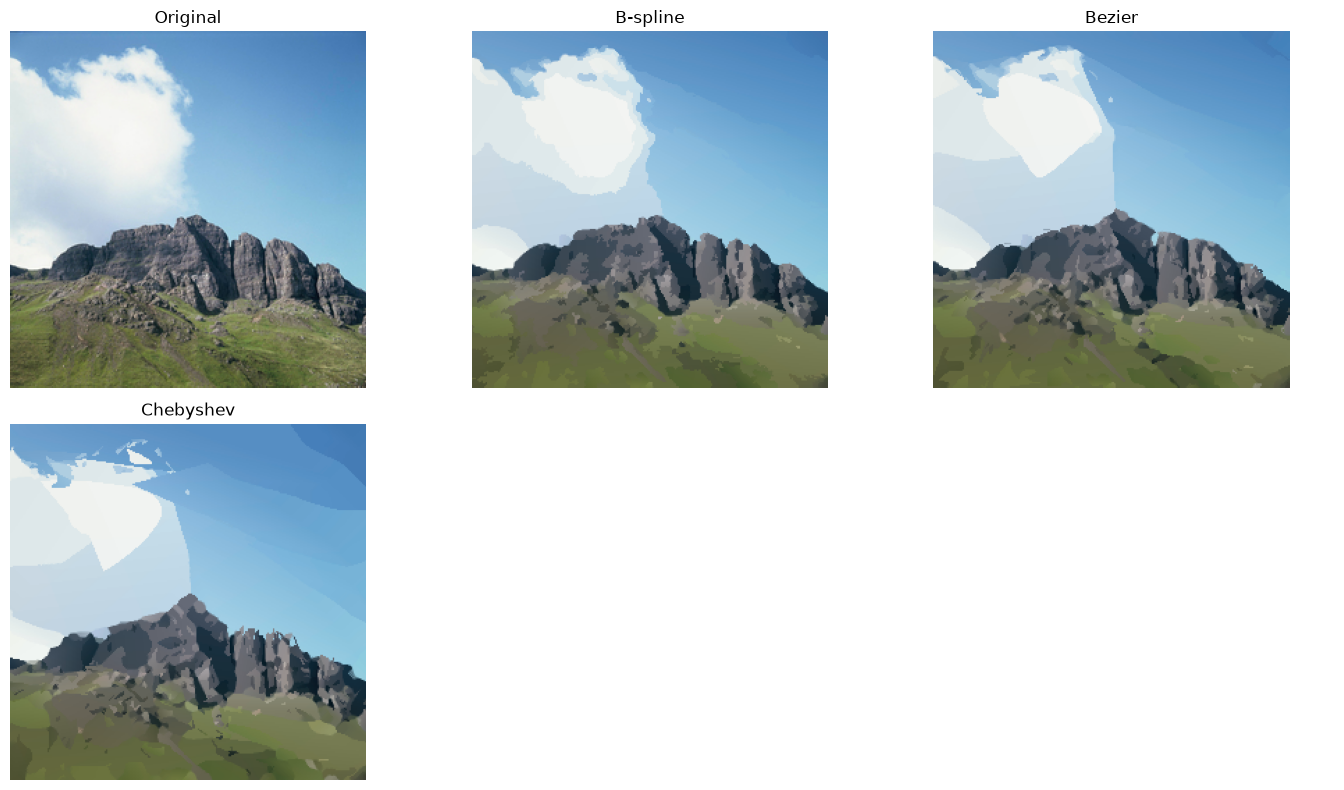

In [18]:
# Compares: Chebyshev, Polyfit, B-spline, Bezier
def boundary_band_from_labels(labels, radius=2):
    H, W = labels.shape
    b = np.zeros((H, W), dtype=np.uint8)
    b[:, :-1] |= (labels[:, :-1] != labels[:, 1:]).astype(np.uint8)
    b[:-1, :] |= (labels[:-1, :] != labels[1:, :]).astype(np.uint8)
    if radius > 0:
        k = np.ones((2 * radius + 1, 2 * radius + 1), dtype=np.uint8)
        b = cv2.dilate(b, k, iterations=1)
    return (b == 1), ~(b == 1)


def masked_mae(orig_rgb, rec_rgb, mask2d):
    d = np.abs(orig_rgb.astype(np.float32) - rec_rgb.astype(np.float32))
    return float(d[mask2d].mean()) if mask2d.sum() > 0 else np.nan


def masked_psnr(orig_rgb, rec_rgb, mask2d):
    e2 = (orig_rgb.astype(np.float32) - rec_rgb.astype(np.float32)) ** 2
    if mask2d.sum() == 0:
        return np.nan
    mse = float(e2[mask2d].mean())
    if mse <= 1e-12:
        return 99.0
    return float(10.0 * np.log10((255.0 ** 2) / mse))


def masked_ssim(orig_rgb, rec_rgb, mask2d):
    maps = []
    for ch in range(3):
        _, s_map = ssim(orig_rgb[:, :, ch], rec_rgb[:, :, ch], data_range=255, full=True)
        maps.append(s_map)
    s_map_rgb = np.mean(np.stack(maps, axis=2), axis=2)
    return float(s_map_rgb[mask2d].mean()) if mask2d.sum() > 0 else np.nan

# Convert HxWx3 uint8 RGB to BCHW float
def img_to_tensor(img_rgb):
    t = torch.from_numpy(img_rgb.astype(np.float32)).permute(2, 0, 1).unsqueeze(0)
    return (t / 127.5) - 1.0

def compute_lpips(orig_rgb, rec_rgb):
    with torch.no_grad():
        return float(lpips_fn(img_to_tensor(orig_rgb), img_to_tensor(rec_rgb)))

def compute_mse(orig_rgb, rec_rgb):
    return float(np.mean((orig_rgb.astype(np.float32) - rec_rgb.astype(np.float32)) ** 2))

# Initialize LPIPS
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lpips_fn = lpips.LPIPS(net='alex', verbose=False)

def report_variant(name, orig_rgb, rec_rgb, band_mask, interior_mask):
    full_mse   = compute_mse(orig_rgb, rec_rgb)
    full_psnr = masked_psnr(orig_rgb, rec_rgb, np.ones(orig_rgb.shape[:2], dtype=bool))
    full_ssim = ssim(orig_rgb, rec_rgb, channel_axis=2, data_range=255)
    full_lpips = compute_lpips(orig_rgb, rec_rgb)

    b_mae = masked_mae(orig_rgb, rec_rgb, band_mask)
    i_mae = masked_mae(orig_rgb, rec_rgb, interior_mask)

    b_psnr = masked_psnr(orig_rgb, rec_rgb, band_mask)
    i_psnr = masked_psnr(orig_rgb, rec_rgb, interior_mask)
    
    b_ssim = masked_ssim(orig_rgb, rec_rgb, band_mask)
    i_ssim = masked_ssim(orig_rgb, rec_rgb, interior_mask)
    print(f'{name}:')
    print(f'  full      MSE={full_mse:.3f}, PSNR={full_psnr:.3f}, SSIM={full_ssim:.4f}, LPIPS={full_lpips:.4f}')
    print(f'  boundary  MAE={b_mae:.3f}, PSNR={b_psnr:.3f}, SSIM={b_ssim:.4f}')
    print(f'  interior  MAE={i_mae:.3f}, PSNR={i_psnr:.3f}, SSIM={i_ssim:.4f}')

orig_rgb = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2RGB)
band_mask, interior_mask = boundary_band_from_labels(imgClusters, radius=2)

variants = [
    ('B-spline', b_spline_compression),
    ('Bezier', bezier_compression),
    ('Chebyshev', cheby_fit_compression),
]
results_rgb = {}

for name, comp_fn in variants:
    open('imComp.txt', 'w').close()
    comp_fn()

    rec_lab = decode_planar_any_geometry('imComp.txt', img.shape[:2])
    rec_rgb = cv2.cvtColor(rec_lab, cv2.COLOR_LAB2RGB)
    results_rgb[name] = rec_rgb

    report_variant(name, orig_rgb, rec_rgb, band_mask, interior_mask)

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
ax = ax.ravel()
items = [('Original', orig_rgb)] + [(k, results_rgb[k]) for k in ['B-spline', 'Bezier', 'Chebyshev']]
for i, (title, img_) in enumerate(items):
    ax[i].imshow(img_)
    ax[i].set_title(title)
    ax[i].axis('off')
for j in range(len(items), len(ax)):
    ax[j].axis('off')
plt.tight_layout()
plt.show()